In [1]:
import pandas as pd

In [4]:
data=pd.read_csv(r'passwords.csv',on_bad_lines='skip')

In [5]:
data.head()

,password,strength
0,kzde5577,1
1,kino3434,1
2,visi7k1yr,1
3,megzy123,1
4,lamborghin1,1


In [ ]:
data.size

In [7]:
data

,password,strength
0,kzde5577,1
1,kino3434,1
2,visi7k1yr,1
3,megzy123,1
4,lamborghin1,1
...,...,...
669635,10redtux10,1
669636,infrared1,1
669637,184520socram,1
669638,marken22a,1


In [8]:
data.isnull().sum()

,0
password,1
strength,0


In [9]:
data.dropna(inplace=True)

In [10]:
data=data.reset_index()

In [11]:
data

,index,password,strength
0,0,kzde5577,1
1,1,kino3434,1
2,2,visi7k1yr,1
3,3,megzy123,1
4,4,lamborghin1,1
...,...,...,...
669634,669635,10redtux10,1
669635,669636,infrared1,1
669636,669637,184520socram,1
669637,669638,marken22a,1


In [12]:
data.drop(columns=['index'],inplace=True)

In [13]:
data.strength.value_counts()

,count
strength,
1,496801
0,89701
2,83137


1. Here we can clearly see that the data is very imbalanced

2. Accuracy can be misleading here

3. We have to consider different metrics to get down to the result

In [14]:
import random
import numpy as np

In [15]:
vect_data=np.array(data)

In [16]:
vect_data

array([['kzde5577', 1],
       ['kino3434', 1],
       ['visi7k1yr', 1],
       ...,
       ['184520socram', 1],
       ['marken22a', 1],
       ['fxx4pw4g', 1]], dtype=object)

In [17]:
random.shuffle(vect_data)

In [18]:
vect_data

array([['kzde5577', 1],
       ['kzde5577', 1],
       ['kino3434', 1],
       ...,
       ['fkbniumc6', 1],
       ['tm800616', 1],
       ['youyan0348087', 1]], dtype=object)

In [19]:
X=[columns[0] for columns in vect_data]

In [20]:
y=[columns[1] for columns in vect_data]

As this the text data and characters in passwords may carry some semantic info

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
def word_to_char(word):
    char=[]
    for letter in word:
        char.append(letter)
    return char

vectoriser=TfidfVectorizer(tokenizer=word_to_char)

train=vectoriser.fit_transform(X)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Lets split the data

In [25]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(train, y, test_size=0.2, random_state=42, stratify=y)

1. We know by seeing the data this is a multinomial logistic regression problem

2. But there is imbalance which cannot be handles by the above model but we still apply it to check the baseline model performance




## Applying Multinomial Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression

mutinomial_logistic = LogisticRegression(multi_class='multinomial', solver='newton-cg')
mutinomial_logistic.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial', solver='newton-cg')

In [29]:
from sklearn.metrics import accuracy_score

y_pred = mutinomial_logistic.predict(x_test)
accuracy_score(y_test, y_pred)


0.8193730959918762

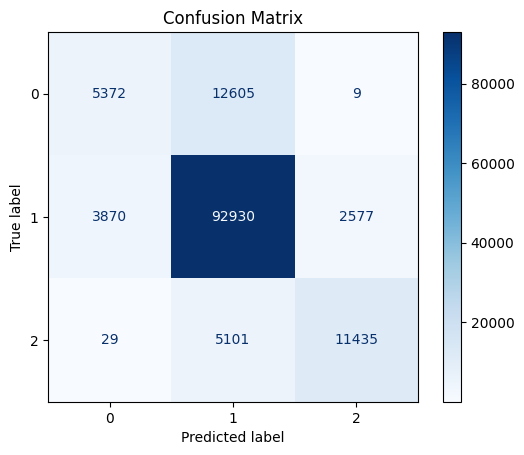

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import  matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()


In [33]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.58      0.30      0.39     17986
           1       0.84      0.94      0.88     99377
           2       0.82      0.69      0.75     16565

    accuracy                           0.82    133928
   macro avg       0.74      0.64      0.68    133928
weighted avg       0.80      0.82      0.80    133928



1. Here we can see that overall accuarcy is high 82%

2. BUT the recall for class 0 (weak passwords) is not 30% that means that 70% of weak passwords are not correctly classified as weak  

3. Now this will create a huge problem as password which is weak and not classified as weak will cause security issue for users



Our prirotiy should be to maximise the recall on class 0 (weak), as it the costliest missclassification


SO what we do now.

1. this clearly means that we this model is only predicting the class 1 most of the time as its the majority class and recall of the same is 94% which upon seeing should be given the imbalance of the data

### We can apply algorithms which handles imbalance well
### We can use Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

# --- 1. Initialize and Train the Random Forest Model ---

rf_classifier = RandomForestClassifier(
    n_estimators=20,          # A good number of trees (adjust for time/performance)
    max_depth=12,              # Allow trees to grow deeply but not excessively
    class_weight='balanced',   # Algorithm-Level Imbalance Fix
    random_state=42,
    n_jobs=-1                  # Use all cores for faster training
)

print("Starting Random Forest Training (with class_weight='balanced')...")
rf_classifier.fit(x_train, y_train)
print("Training Complete.")


# --- 2. Prediction and Comprehensive Evaluation ---
y_pred = rf_classifier.predict(x_test)

# Calculate Overall Accuracy (for comparison to the 82% LR baseline)
accuracy = rf_classifier.score(x_test, y_test)

# Evaluation: Use Classification Report and Confusion Matrix
print("\n--- Model Evaluation: Random Forest Classifier ---")
print(f"Overall Accuracy: {accuracy:.4f}")

print("\n--- CLASSIFICATION REPORT (The Essential Metric for Imbalance) ---")
# Look closely at the Recall for Class 0!
print(classification_report(y_test, y_pred))

print("\n--- CONFUSION MATRIX ---")
# The matrix will show where misclassifications occur (e.g., how often Class 0 is missed)
print(confusion_matrix(y_test, y_pred))

Starting Random Forest Training (with class_weight='balanced')...
Training Complete.

--- Model Evaluation: Random Forest Classifier ---
Overall Accuracy: 0.8614

--- CLASSIFICATION REPORT (The Essential Metric for Imbalance) ---
              precision    recall  f1-score   support

           0       0.57      0.89      0.69     17986
           1       0.97      0.84      0.90     99377
           2       0.80      0.95      0.87     16565

    accuracy                           0.86    133928
   macro avg       0.78      0.89      0.82    133928
weighted avg       0.90      0.86      0.87    133928


--- CONFUSION MATRIX ---
[[15941  1925   120]
 [11916 83649  3812]
 [  184   610 15771]]


1. Here we can see that recall on class 0 (weak) has jumped from 30% (multinomial logistic regression) to 89% (in RF)

2. This clearly tells us that the misclassification of minority class is penalised

3. Although this is a good recall but what if we want more ??  
   Can we Better than this??

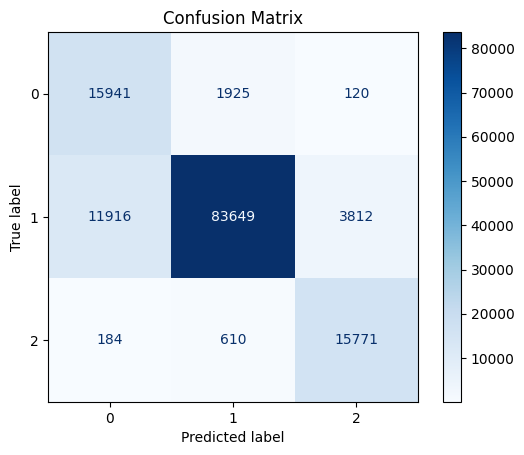

In [35]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

We can apply threshold tuning   

Tahe goal is to re-classify samples where the model shows low confidence that the password is weak (Class 0) but that classification is crucial for security.  

We are trying that can we push recall aboveb 90% such that precision does not go down much

In [36]:

y_proba = rf_classifier.predict_proba(x_test)

# y_proba is a NumPy array with 3 columns (Prob_Class_0, Prob_Class_1, Prob_Class_2)

# Focusing on the security-critical class (Class 0) ---
# Extract the probabilities for Class 0 (the weakest passwords)
proba_class_0 = y_proba[:, 0]

In [37]:
# Test thresholds from 0.5 down to 0.1, in small steps
thresholds = np.arange(0.5, 0.05, -0.05)

In [38]:
from sklearn.metrics import recall_score, precision_score

print("\n--- Threshold Tuning Results for Class 0 (Weak Passwords) ---")
print("Threshold | Recall (0) | Precision (0) | F1-Score (0)")
print("---------------------------------------------------------")

best_f1_score = 0
best_threshold = 0

for threshold in thresholds:
    # Re-classifying out data
    # Predict Class 0 if P(Class 0) >= t, otherwise let the model assign 1 or 2
    y_pred_new = np.argmax(y_proba / threshold, axis=1) # A simplified way to bias prediction

    # Calculate metrics focusing only on Class 0 (weak passwords)
    recall_0 = recall_score(y_test, y_pred_new, labels=[0, 1, 2], average='weighted', zero_division=0)
    precision_0 = precision_score(y_test, y_pred_new, labels=[0, 1, 2], average='weighted', zero_division=0)
    f1_0 = 2 * (precision_0 * recall_0) / (precision_0 + recall_0)

    # We must look specifically at the F1-score for Class 0 only.
    recall_weak = recall_score(y_test, y_pred_new, labels=[0], average='macro', zero_division=0)
    precision_weak = precision_score(y_test, y_pred_new, labels=[0], average='macro', zero_division=0)
    f1_weak = 2 * (precision_weak * recall_weak) / (precision_weak + recall_weak)

    print(f"{threshold:.2f}      | {recall_weak:.4f}     | {precision_weak:.4f}      | {f1_weak:.4f}")

    if f1_weak > best_f1_score:
        best_f1_score = f1_weak
        best_threshold = threshold

print(f"\nOptimal Threshold for Class 0 (based on F1-Score): {best_threshold:.2f}")


--- Threshold Tuning Results for Class 0 (Weak Passwords) ---
Threshold | Recall (0) | Precision (0) | F1-Score (0)
---------------------------------------------------------
0.50      | 0.8863     | 0.5685      | 0.6927
0.45      | 0.8863     | 0.5685      | 0.6927
0.40      | 0.8863     | 0.5685      | 0.6927
0.35      | 0.8863     | 0.5685      | 0.6927
0.30      | 0.8863     | 0.5685      | 0.6927
0.25      | 0.8863     | 0.5685      | 0.6927
0.20      | 0.8863     | 0.5685      | 0.6927
0.15      | 0.8863     | 0.5685      | 0.6927
0.10      | 0.8863     | 0.5685      | 0.6927

Optimal Threshold for Class 0 (based on F1-Score): 0.50


1. here we observe that the recall is staaying same for every thereshold

2. This clearly tells us that the prob of majority is so high that even going to threshold = 0.05 the probablity of class 0 does not surpass the largest probablity  

---

1. We can do direct threshold withotu dividing


In [40]:
import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score

# Probabilities for Class 0 (Weak Passwords)
proba_class_0 = y_proba[:, 0]

# Define the thresholds to test
thresholds = np.arange(0.50, 0.05, -0.05)

print("Threshold | Recall (C0) | Precision (C0) | F1-Score (C0)")
print("---------------------------------------------------------")

best_f1_weak = 0
best_threshold = 0

for threshold in thresholds:
    # --- CRITICAL CHANGE: Custom Prediction Logic ---
    # 1. Start with the original predictions (the highest probability among all classes)
    y_pred_original = np.argmax(y_proba, axis=1)

    y_pred_biased = np.copy(y_pred_original)

    # we are forcing the prediction to Class 0 where its probability exceeds the threshold and protitise class 0
    y_pred_biased[proba_class_0 >= threshold] = 0
    # ----------------------------------------------------

    # Calculate the security-critical metrics (Class 0 only)
    # Using 'weighted' or 'macro' with labels=[0] works if only one class is present
    recall_weak = recall_score(y_test, y_pred_biased, labels=[0], average='macro', zero_division=0)
    precision_weak = precision_score(y_test, y_pred_biased, labels=[0], average='macro', zero_division=0)
    f1_weak = 2 * (precision_weak * recall_weak) / (precision_weak + recall_weak)

    print(f"{threshold:.2f}      | {recall_weak:.4f}     | {precision_weak:.4f}      | {f1_weak:.4f}")

    # Track the best F1-score for the weak class
    if f1_weak > best_f1_weak:
        best_f1_weak = f1_weak
        best_threshold = threshold

print("\n---------------------------------------------------------")
print(f"Best Threshold for Weak Passwords (Class 0 F1): {best_threshold:.2f}")
print(f"Best F1 Score (Class 0): {best_f1_weak:.4f}")

Threshold | Recall (C0) | Precision (C0) | F1-Score (C0)
---------------------------------------------------------
0.50      | 0.8863     | 0.5685      | 0.6927
0.45      | 0.8916     | 0.5624      | 0.6898
0.40      | 0.9371     | 0.4709      | 0.6268
0.35      | 0.9709     | 0.3584      | 0.5235
0.30      | 0.9905     | 0.2724      | 0.4273
0.25      | 0.9975     | 0.2164      | 0.3556
0.20      | 0.9993     | 0.1809      | 0.3064
0.15      | 0.9998     | 0.1597      | 0.2755
0.10      | 1.0000     | 0.1472      | 0.2567

---------------------------------------------------------
Best Threshold for Weak Passwords (Class 0 F1): 0.50
Best F1 Score (Class 0): 0.6927


#### Here we can see the tradeoff between recall and prescision

1. Threshold = 0.5 seems to be the best option with f1-score beign the highest

2. But can we consider threshold = 0.45 . It does not increase the recall much and neither decrease the prescision much

3. Can we consider threshold = 0.40 where recall is around 94% but precision drop to 47%, which is huge dip

4. Now the question is how much low precision we can afford.

In [43]:
import warnings
warnings.filterwarnings('ignore')

### Comparing Vectorization Techniques

Let's compare the performance of Multinomial Logistic Regression with different vectorization techniques: Word2Vec, TF-IDF (which we've already used), and CountVectorizer. We will evaluate each using the classification report, focusing on the recall for class 0.

In [47]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split data for this comparison
# Use the same random_state for consistent splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define a function to tokenize words into characters
def word_to_char(word):
    char=[]
    for letter in word:
        char.append(letter)
    return char

print("--- Evaluating CountVectorizer ---")
count_vectorizer = CountVectorizer(tokenizer=word_to_char)
X_train_cv = count_vectorizer.fit_transform(X_train)
X_test_cv = count_vectorizer.transform(X_test)

multinomial_logistic_cv = LogisticRegression(multi_class='multinomial', solver='newton-cg', max_iter=1000) # Increased max_iter
multinomial_logistic_cv.fit(X_train_cv, y_train)
y_pred_cv = multinomial_logistic_cv.predict(X_test_cv)
print(classification_report(y_test, y_pred_cv, zero_division=0))

print("\n--- Evaluating TfidfVectorizer ---")
# We've already used TfidfVectorizer, but let's re-run for a clean comparison
tfidf_vectorizer = TfidfVectorizer(tokenizer=word_to_char)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

multinomial_logistic_tfidf = LogisticRegression(multi_class='multinomial', solver='newton-cg', max_iter=1000) # Increased max_iter
multinomial_logistic_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = multinomial_logistic_tfidf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_tfidf, zero_division=0))

--- Evaluating CountVectorizer ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17986
           1       1.00      1.00      1.00     99377
           2       1.00      1.00      1.00     16565

    accuracy                           1.00    133928
   macro avg       1.00      1.00      1.00    133928
weighted avg       1.00      1.00      1.00    133928


--- Evaluating TfidfVectorizer ---
              precision    recall  f1-score   support

           0       0.58      0.30      0.39     17986
           1       0.84      0.94      0.89     99377
           2       0.82      0.69      0.75     16565

    accuracy                           0.82    133928
   macro avg       0.75      0.64      0.68    133928
weighted avg       0.80      0.82      0.80    133928



1. Here we see that countvectoriser data provide us the perfect metrics

2. This is suspicious

3. But all the metrics are perfect??

### We can checkt the model performance on 3 different, randomly-held-out validation sets

In [46]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Re-initialize the RF classifier
rf_cv = RandomForestClassifier(n_estimators=20, max_depth=12, random_state=42, class_weight='balanced')

# Use cross_val_score on the full 'train' data (before the final X_test split)
# Use 3 or 5 folds (cv=3 or cv=5)
cv_scores = cross_val_score(rf_cv, X_train_cv, y_train, cv=3, scoring='f1_weighted', n_jobs=-1)

print("Cross-Validation F1 Scores:", cv_scores)
print("Mean CV F1 Score:", cv_scores.mean())

Cross-Validation F1 Scores: [0.67871096 0.67534971 0.67857589]
Mean CV F1 Score: 0.6775455211658233


Here we are modelling RandomForest and we see that the overall mean score of different random validation sets is only 67.7%

Seems like it is oervfitting as Random forest is providing us a generalised model whose performance is much lower than 100%

### Using GridSearchCV for Hyperparameter Tuning

Yes, we can apply GridSearchCV to find the best parameters for the vectorizers and the RF model. However, due to the size of the dataset and the dimensionality of the vectorized data, This takes a lot if time
We can create a pipeline that includes the vectorizer and the logistic regression model and then use GridSearchCV on the pipeline.

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np

# --- 1. Define Model and Parameter Grid ---
# We use a slightly broader parameter space to search for the optimal model.

# Initialize the classifier with the imbalance fix
# Note: Use the sparse TF-IDF data ('train' and 'y_array') for best results
rf_gs = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Define the parameter grid
param_grid = {
    # Number of trees (Trade-off: Performance vs. Speed)
    'n_estimators': [15, 20],

    # Max depth of the tree (Trade-off: Bias vs. Variance/Overfitting)
    'max_depth': [10, 12, 14],

    # Number of features to consider for each split (Improves diversity/reduces overfitting)
    'max_features': ['sqrt', 0.5]
}

# --- 2. Implement Grid Search with Cross-Validation ---
print("Starting GridSearchCV (This will take significant time as it runs 4*4*2*3 = 96 fits)...")

# We use f1_weighted as the scoring metric because it accurately reflects
# performance across the imbalanced classes.
grid_search = GridSearchCV(
    estimator=rf_gs,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,                  # Use 3-fold cross-validation
    verbose=2,             # Show progress
    n_jobs=-1              # Use all cores
)

# Fit the search on the entire TF-IDF training data
# NOTE: The search will be slow due to the large dataset and the number of fits.
# Assuming X_train and y_train were defined using TF-IDF's 'train' and 'y_array'.
grid_search.fit(X_train_tfidf, y_train)

# --- 3. Evaluate the Best Model ---

best_rf_model = grid_search.best_estimator_
y_pred_gs = best_rf_model.predict(X_test_tfidf)

print("\n--- Final GridSearch Results ---")
print(f"Best Hyperparameters found: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

print("\n--- CLASSIFICATION REPORT (Best Model on Unseen Test Set) ---")
# Final check on the unseen test data
print(classification_report(y_test, y_pred_gs))

Starting GridSearchCV (This will take significant time as it runs 4*4*2*3 = 96 fits)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

--- Final GridSearch Results ---
Best Hyperparameters found: {'max_depth': 14, 'max_features': 0.5, 'n_estimators': 20}
Best CV F1 Score: 0.8998

--- CLASSIFICATION REPORT (Best Model on Unseen Test Set) ---
              precision    recall  f1-score   support

           0       0.65      0.90      0.76     17986
           1       0.98      0.89      0.93     99377
           2       0.86      0.96      0.91     16565

    accuracy                           0.90    133928
   macro avg       0.83      0.92      0.86    133928
weighted avg       0.92      0.90      0.90    133928



Here we observe that we achived around 90% f1 score  

We also achieved 90% recall on class 0 and its prescision is also 65% better than before



# In place of SMOTE for oversampling, we have used RF which handles imbalance

# SMOTE is a time taking process but RF is much faster than this